# Face Recognition

## Importing Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [1]:
import cv2
from google.colab.patches import cv2_imshow

In [5]:
!pip install keras_applications

     |████████████████████████████████| 51kB 4.9MB/s 


In [29]:
import tensorflow as tf
import keras_applications
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from scipy.spatial.distance import cosine

We use pretrained model VGG-Face for creating face embeddings.

In [10]:
!pip install git+https://github.com/rcmalli/keras-vggface.git

  Cloning https://github.com/rcmalli/keras-vggface.git to /tmp/pip-req-build-uf1ggu2q
  Running command git clone -q https://github.com/rcmalli/keras-vggface.git /tmp/pip-req-build-uf1ggu2q
  Created wheel for keras-vggface: filename=keras_vggface-0.6-cp36-none-any.whl size=8310 sha256=2652917377543c959076f96741f4432226e75d4190f7e58f953b14341d90e408
  Stored in directory: /tmp/pip-ephem-wheel-cache-gssw1tec/wheels/36/07/46/06c25ce8e9cd396dabe151ea1d8a2bc28dafcb11321c1f3a6d
Successfully built keras-vggface


In [19]:
from keras_vggface.vggface import VGGFace

## Extracting and preparing the dataset

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle

!chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle datasets download -d hereisburak/pins-face-recognition --unzip

 99% 367M/372M [00:03<00:00, 119MB/s]
100% 372M/372M [00:03<00:00, 98.7MB/s]


In [13]:
classes=os.listdir('105_classes_pins_dataset')

We take the first 20 classes.

In [14]:
classes_lim=20

Now we create X which stores the images resized into 224,224 dimensions.

We also create Y which stores the output labels encoded into numbers from 0 to 19.

In [15]:
X=[]
Y=[]

IMG_SIZE=224

for i in range(classes_lim):
  class_i=os.listdir('105_classes_pins_dataset/'+classes[i])
  print('105_classes_pins_dataset/'+classes[i])
  for j in class_i:
    img=cv2.imread('105_classes_pins_dataset/'+classes[i]+'/'+j)
    # X.append(cv2.resize(img, (100, 100)))
    if(len(X)==0):
      X=cv2.resize(img, (IMG_SIZE, IMG_SIZE))
      X=X.reshape(1,X.shape[0],X.shape[1],X.shape[2])
    else:  
      X=np.append(X,[cv2.resize(img, (IMG_SIZE, IMG_SIZE))],axis=0)
    Y.append(i)

Y=np.array(Y)

105_classes_pins_dataset/pins_tom ellis
105_classes_pins_dataset/pins_Miley Cyrus
105_classes_pins_dataset/pins_Chris Pratt
105_classes_pins_dataset/pins_Rihanna
105_classes_pins_dataset/pins_Sophie Turner
105_classes_pins_dataset/pins_Maisie Williams
105_classes_pins_dataset/pins_Avril Lavigne
105_classes_pins_dataset/pins_Emma Watson
105_classes_pins_dataset/pins_Eliza Taylor
105_classes_pins_dataset/pins_Emilia Clarke
105_classes_pins_dataset/pins_Tom Holland
105_classes_pins_dataset/pins_Katherine Langford
105_classes_pins_dataset/pins_Rami Malek
105_classes_pins_dataset/pins_barbara palvin
105_classes_pins_dataset/pins_melissa fumero
105_classes_pins_dataset/pins_Lindsey Morgan
105_classes_pins_dataset/pins_Tom Cruise
105_classes_pins_dataset/pins_Emma Stone
105_classes_pins_dataset/pins_Megan Fox
105_classes_pins_dataset/pins_Zac Efron


Let's view some of the faces.

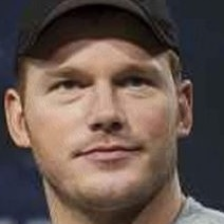

In [50]:
cv2_imshow(X[420])

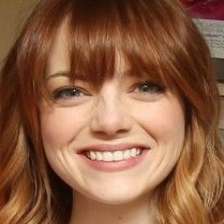

In [49]:
cv2_imshow(X[3135])

## Importing face recognition model

In [20]:
model = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3), pooling='avg')

94699520/94694792 [==============================] - 2s 0us/step


Now we generate the embedding correspoinding to all the images.

In [21]:
face_Y=model.predict(X)

## Using Cosine distance as metric

Cosine distance is used to measure the similarity between two non-zero vectors.

Less value of cosine distance means the vectors are similar.

### Same class

In [51]:
score = cosine(face_Y[0], face_Y[1])
print(score)

0.38783538341522217


### Different class

In [52]:
score = cosine(face_Y[0], face_Y[400])
print(score)

0.7067492604255676


## Dimension Reduction using PCA

In [24]:
face_Y.shape

(3635, 2048)

We can see that the embeddings vectors have 2048 dimensions. 

We reduce the dimensions into 100 using PCA.

In [25]:
pca=PCA(n_components=100)
X_pca=pca.fit_transform(face_Y)

In [26]:
X_pca.shape

(3635, 100)

We split the data into 80% for training and 20% for testing data. 

In [28]:
X_train, X_test, Y_train, Y_test=train_test_split(X_pca,Y,test_size=0.2,random_state=42)

## SVM

We build a support vector machine. 

Since this is multiclass classification, we use 'one-versus-one' approach.

In [31]:
svm=SVC(decision_function_shape='ovo')
svm.fit(X_train,Y_train)

SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovo', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [32]:
accuracy_score(Y_train,svm.predict(X_train))

0.999656121045392

In [33]:
accuracy_score(Y_test,svm.predict(X_test))

0.9958734525447043

In [ ]:
We can see that for both training and testing data we get around 99% accuracy.